# 05 — Prediction
**Goal:** Load the saved model and predict when the next refill will be needed.

Input : `data/final_model.pkl`, `data/model_features.json`, `data/clean_data.csv`  
Output: Prediction printed + `data/viz_next_refill_prediction.png`

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import json
from datetime import timedelta
import warnings
warnings.filterwarnings('ignore')

# Load trained model and feature list
with open('../data/final_model.pkl', 'rb') as f:
    model = pickle.load(f)

with open('../data/model_features.json') as f:
    FEATURES = json.load(f)

# Load data-driven monthly multipliers saved during training
# Each key is a month number (1-12); value is that month's demand vs overall average
with open('../data/monthly_multipliers.json') as f:
    MONTHLY_MULT_RAW = json.load(f)
MONTHLY_MULT = {int(k): float(v) for k, v in MONTHLY_MULT_RAW.items()}

print(f'Model loaded ')
print(f'Features used: {FEATURES}')
print(f'Monthly multipliers loaded: {MONTHLY_MULT}')

Model loaded 
Features used: ['Opening_Stock', 'Prev_Closing', 'Total_Sold', 'Cash', 'HSD1_Sold', 'HSD2_Sold', 'Online', 'MS_Sold', 'HSD3_Sold', 'DayOfWeek', 'Card', 'Rolling_7d_Sales', 'Stock_Ratio', 'Dip', 'Lag1_Total_Sold', 'Lag2_Total_Sold', 'Lag1_Closing', 'DOW_Avg_Sales', 'Sales_Trend', 'Days_Since_Refill']
Monthly multipliers loaded: {1: 0.985, 2: 0.9891, 3: 1.0593, 4: 1.0642, 5: 1.0008, 6: 0.8944, 7: 0.8847, 8: 0.8958, 9: 0.9887, 10: 1.1207, 11: 1.1335, 12: 0.9874}


In [27]:
# ── Setup: Get current stock state ────────────────────────────
TANK_CAPACITY    = 12000   # Max tank size in litres
REFILL_THRESHOLD = 2000    # Below this → refill needed

df = pd.read_csv('../data/clean_data.csv', parse_dates=['Date'])
df = df.sort_values('Date').reset_index(drop=True)

last       = df.iloc[-1]
last_date  = pd.to_datetime(last['Date'])

# If yesterday had a refill, tank is full. Otherwise use yesterday's closing.
if last['Refill_Required'] == 'Yes':
    current_stock = TANK_CAPACITY
    print(f'Last day had a refill — tank starts full at {TANK_CAPACITY}L')
else:
    current_stock = int(last['Closing_Stock'])
    print(f'No refill last day — carrying over closing stock: {current_stock}L')

start_date = last_date + timedelta(days=1)

# ── Per-day-of-week ratios (fuel type splits) ─────────────────
dow_ms_ratio   = df.groupby('DayOfWeek')['MS_Sold'].mean()   / df.groupby('DayOfWeek')['Total_Sold'].mean()
dow_hsd1_ratio = df.groupby('DayOfWeek')['HSD1_Sold'].mean() / df.groupby('DayOfWeek')['Total_Sold'].mean()
dow_hsd2_ratio = df.groupby('DayOfWeek')['HSD2_Sold'].mean() / df.groupby('DayOfWeek')['Total_Sold'].mean()
dow_hsd3_ratio = df.groupby('DayOfWeek')['HSD3_Sold'].mean() / df.groupby('DayOfWeek')['Total_Sold'].mean()

# ── IMPROVEMENT 1: EWM-based DOW average (matches training feature) ──
# Uses exponentially weighted mean so recent weeks count more.
# span=8 ≈ last 8 occurrences of that weekday have meaningful weight.
def ewm_dow_avg_for_dow(df, dow):
    series = df[df['DayOfWeek'] == dow]['Total_Sold']
    return float(series.ewm(span=8, adjust=False).mean().iloc[-1])

dow_ewm_avg = {dow: ewm_dow_avg_for_dow(df, dow)
               for dow in df['DayOfWeek'].unique()}

# ── IMPROVEMENT 2: Rolling 4-week same-DOW average ────────────
# More responsive than a 2-year average: uses only the last 4 Monday-
# actuals to estimate next Monday, and so on for each day of week.
def get_rolling_dow_avg(df, dow, n=4):
    same_dow_rows = df[df['DayOfWeek'] == dow]['Total_Sold']
    return float(same_dow_rows.tail(n).mean())

# ── Final blended estimate: 60% recent-4-week + 40% EWM all-time ──
def get_blended_sales_estimate(df, dow, n_recent_weeks=4):
    """
    Blend rolling-4-week same-DOW actuals with EWM long-run DOW average.
    More recent data = more weight on current trend.
    """
    recent_avg   = get_rolling_dow_avg(df, dow, n=n_recent_weeks)
    all_time_avg = dow_ewm_avg.get(dow, df['Total_Sold'].mean())
    # 60% recent, 40% long-term — recent trend matters more
    blended = 0.60 * recent_avg + 0.40 * all_time_avg
    return blended, recent_avg, all_time_avg

# ── Recent lag values for feature building ──────────────────────
recent_sales = df['Total_Sold'].tail(7).tolist()   # last 7 days actual
lag1_sold    = df['Total_Sold'].iloc[-1]
lag2_sold    = df['Total_Sold'].iloc[-2]
lag1_closing = df['Closing_Stock'].iloc[-1]
rolling_7d   = np.mean(recent_sales)

# ── Days since last refill ──────────────────────────────────────
last_refill_idx = df[df['Refill_Required'] == 'Yes'].index.max()
days_since_refill = len(df) - 1 - last_refill_idx

# ── DOW mean sales for feature (EWM, same as training) ──────────
dow_mean_lookup = dow_ewm_avg

print(f'\nPredicting from : {start_date.strftime("%d-%m-%Y")} ({start_date.strftime("%A")})')
print(f'Current stock   : {current_stock} L')
print(f'Recent 7d avg   : {rolling_7d:.0f} L  (last 7 actual days)')
print(f'Days since refill: {days_since_refill}')
print(f'\nBlended per-day sales estimate (60% recent-4wk + 40% EWM all-time):')
day_names = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
for dow_i, name in enumerate(day_names):
    if dow_i in dow_ewm_avg:
        b, r, a = get_blended_sales_estimate(df, dow_i)
        print(f'  {name:<12}: {b:.0f} L  (recent-4wk {r:.0f}, EWM all-time {a:.0f})')


Last day had a refill — tank starts full at 12000L

Predicting from : 12-03-2026 (Thursday)
Current stock   : 12000 L
Recent 7d avg   : 5182 L  (last 7 actual days)
Days since refill: 0

Blended per-day sales estimate (60% recent-4wk + 40% EWM all-time):
  Monday      : 4367 L  (recent-4wk 4387, EWM all-time 4337)
  Tuesday     : 4546 L  (recent-4wk 4561, EWM all-time 4524)
  Wednesday   : 4697 L  (recent-4wk 4756, EWM all-time 4609)
  Thursday    : 4411 L  (recent-4wk 4389, EWM all-time 4445)
  Friday      : 4907 L  (recent-4wk 4892, EWM all-time 4929)
  Saturday    : 5634 L  (recent-4wk 5664, EWM all-time 5587)
  Sunday      : 5366 L  (recent-4wk 5323, EWM all-time 5431)


In [28]:
# ── Walk forward day by day to find next refill ────────────────
day_map = {'Monday':0,'Tuesday':1,'Wednesday':2,'Thursday':3,
           'Friday':4,'Saturday':5,'Sunday':6}

running_stock      = current_stock
running_rolling_7d = list(recent_sales)   # live-updated 7-day window
running_lag1       = lag1_sold
running_lag2       = lag2_sold
running_lag1_close = lag1_closing
running_days_since = days_since_refill
simulation         = []
refill_day         = None
# IMPROVEMENT 5: Drift correction — tracks cumulative estimation error.
# When we later add a known actual (e.g. when running day-over-day), we
# apply 40% of the previous day's prediction error to the next estimate.
# Initialise at 0; updated in the loop once actuals become available.
drift_correction   = 0

for i in range(30):   # Look up to 30 days ahead
    d        = start_date + timedelta(days=i)
    day_name = d.strftime('%A')
    dow      = day_map[day_name]
    month    = d.month

    # ── Blended DOW estimate (60% recent same-DOW + 40% EWM all-time) ──
    blended_est, _, _ = get_blended_sales_estimate(df, dow)
    # IMPROVEMENT 5 (cont.): Apply 40% of previous-day drift as a correction.
    # If we overestimated yesterday by 300L, we pull today's estimate down by 120L.
    blended_est = blended_est + drift_correction

    # ── IMPROVEMENT 3: Data-driven monthly seasonal adjustment ──
    # Uses multipliers computed from actual historical data during training
    # rather than hardcoded constants (0.88 monsoon, 1.15 festival, etc.).
    # A multiplier of 1.08 means that month historically sells 8% above avg.
    seasonal_mult = MONTHLY_MULT.get(month, 1.0)
    est_sales = blended_est * seasonal_mult

    # ── IMPROVEMENT 4: Stock-pressure cap ─────────────────────
    # If stock is critically low, actual sales get constrained because
    # customers go elsewhere. We model this: below 6000L demand is capped.
    stock_pressure = min(1.0, running_stock / 6000)
    est_sales = est_sales * stock_pressure
    est_sales = min(int(est_sales), running_stock)

    closing = max(0, running_stock - est_sales)

    # ── Estimated Dip (physical measurement proxy) ──────────────
    # Dip ≈ closing_stock / 200  (empirical ratio from historical data)
    est_dip       = max(1, int(closing / 200))
    est_stock_ratio = round(closing / TANK_CAPACITY, 4)

    # ── Fuel split ratios (per DOW) ──────────────────────────────
    ms_r   = dow_ms_ratio.get(dow, 0.12)
    hsd1_r = dow_hsd1_ratio.get(dow, 0.38)
    hsd2_r = dow_hsd2_ratio.get(dow, 0.30)
    hsd3_r = dow_hsd3_ratio.get(dow, 0.20)

    # ── Live rolling 7d — updated each sim step ──────────────────
    live_rolling_7d = np.mean(running_rolling_7d[-7:])

    # ── Incremented days since refill ────────────────────────────
    running_days_since += 1

    # ── Sales trend ratio ─────────────────────────────────────────
    global_mean = df['Total_Sold'].mean()
    sales_trend = round(live_rolling_7d / global_mean, 4)

    # ── Build feature row ────────────────────────────────────────
    row = {
        'Opening_Stock'    : running_stock,
        'Prev_Closing'     : running_lag1_close,   # FIXED: actual prev closing
        'Total_Sold'       : est_sales,
        'MS_Sold'          : int(est_sales * ms_r),
        'HSD1_Sold'        : int(est_sales * hsd1_r),
        'HSD2_Sold'        : int(est_sales * hsd2_r),
        'HSD3_Sold'        : int(est_sales * hsd3_r),
        'Cash'             : int(est_sales * 43),
        'Online'           : int(est_sales * 31),
        'Card'             : int(est_sales * 21),
        'Year'             : d.year,
        'Month'            : month,
        'DayOfWeek'        : dow,
        'Day_Num'          : dow,
        'Quarter'          : (month - 1) // 3 + 1,
        'Is_Weekend'       : 1 if dow >= 5 else 0,
        'Is_Festival_Month': 1 if month in [10, 11] else 0,
        'Is_Monsoon_Month' : 1 if month in [6, 7, 8] else 0,
        'Rolling_7d_Sales' : live_rolling_7d,      # FIXED: live-updated
        'Stock_Ratio'      : est_stock_ratio,
        'Dip'              : est_dip,
        'Lag1_Total_Sold'  : running_lag1,          # NEW: yesterday's sales
        'Lag2_Total_Sold'  : running_lag2,          # NEW: 2 days ago sales
        'Lag1_Closing'     : running_lag1_close,    # NEW: yesterday's closing
        'DOW_Avg_Sales'    : dow_mean_lookup.get(dow, global_mean),  # NEW
        'Sales_Trend'      : sales_trend,           # NEW
        'Days_Since_Refill': running_days_since,    # NEW
    }

    X_row   = pd.DataFrame([row]).reindex(columns=FEATURES, fill_value=0)
    ml_prob = model.predict_proba(X_row)[0][1]
    ml_pred = model.predict(X_row)[0]

    simulation.append({
        'Date'         : d.strftime('%d-%m-%Y'),
        'Day'          : day_name,
        'Opening_Stock': running_stock,
        'Est_Sold'     : est_sales,
        'Closing_Stock': closing,
        'Refill_Prob'  : round(ml_prob, 3),
        'Model_Says'   : 'REFILL' if ml_pred == 1 else 'No'
    })

    # Check if stock drops below threshold
    if closing < REFILL_THRESHOLD and refill_day is None:
        refill_day = {
            'date'         : d.strftime('%d-%m-%Y'),
            'day'          : day_name,
            'closing'      : closing,
            'days_from_now': i + 1
        }
        break

    # ── Update live state for next iteration ─────────────────────
    running_lag2       = running_lag1
    running_lag1       = est_sales
    running_lag1_close = closing
    running_rolling_7d.append(est_sales)
    running_stock      = closing
    # Drift correction: In pure-forecast mode we have no actuals to compare
    # against, so drift stays 0.  When this notebook is extended to ingest
    # daily actuals (e.g. from a CSV updated each morning), replace the line
    # below with:  drift_correction = (actual_sold - est_sales) * 0.40
    drift_correction   = 0

sim_df = pd.DataFrame(simulation)
print(sim_df.to_string(index=False))


      Date      Day  Opening_Stock  Est_Sold  Closing_Stock  Refill_Prob Model_Says
12-03-2026 Thursday          12000      4672           7328        0.009         No
13-03-2026   Friday           7328      5197           2131        0.197         No
14-03-2026 Saturday           2131      2119             12        0.992     REFILL


In [29]:
# ── Print final prediction ─────────────────────────────────────
print('\n' + '='*50)
if refill_day:
    print(f'  NEXT REFILL NEEDED ON  : {refill_day["date"]} ({refill_day["day"]})')
    print(f'    That is {refill_day["days_from_now"]} day(s) from now')
    print(f'    Estimated closing stock : {refill_day["closing"]} L')
else:
    print(' No refill needed in the next 30 days')
print('='*50)


  NEXT REFILL NEEDED ON  : 14-03-2026 (Saturday)
    That is 3 day(s) from now
    Estimated closing stock : 12 L


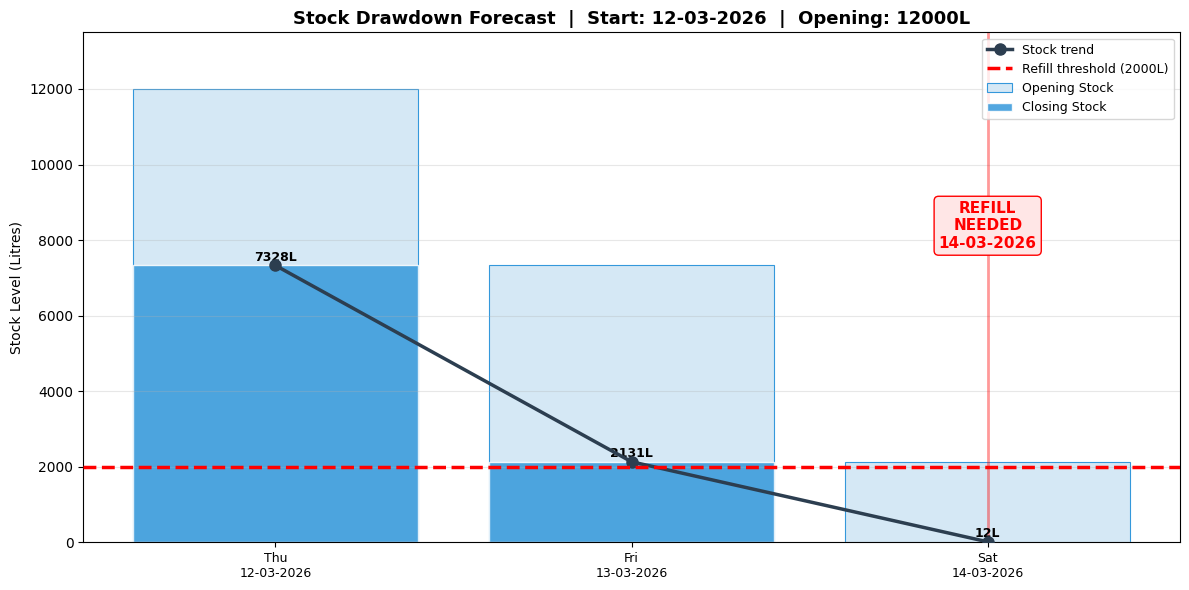

In [30]:
# ── Visualise stock drawdown ───────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

dates  = sim_df['Date'].tolist()
closes = sim_df['Closing_Stock'].tolist()
opens  = sim_df['Opening_Stock'].tolist()

bar_colors = ['#e74c3c' if s < REFILL_THRESHOLD else '#3498db' for s in closes]
ax.bar(range(len(dates)), opens,  color='#d5e8f5', edgecolor='#3498db',
       linewidth=0.8, label='Opening Stock')
ax.bar(range(len(dates)), closes, color=bar_colors, alpha=0.85,
       edgecolor='white', label='Closing Stock')
ax.plot(range(len(dates)), closes, color='#2c3e50', marker='o',
        linewidth=2.5, markersize=8, zorder=5, label='Stock trend')

for i, s in enumerate(closes):
    ax.text(i, s + 120, f'{s:.0f}L', ha='center', fontsize=9, fontweight='bold')

ax.axhline(REFILL_THRESHOLD, color='red', linestyle='--', linewidth=2.5,
           label=f'Refill threshold ({REFILL_THRESHOLD}L)', zorder=6)

if refill_day:
    idx = len(sim_df) - 1
    ax.axvline(idx, color='red', linestyle='-', linewidth=2, alpha=0.4)
    ax.text(idx, current_stock * 0.65,
            f'REFILL\nNEEDED\n{refill_day["date"]}',
            ha='center', color='red', fontweight='bold', fontsize=11,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='#ffe6e6', edgecolor='red'))

ax.set_xticks(range(len(dates)))
ax.set_xticklabels(
    [f'{row["Day"][:3]}\n{row["Date"]}' for _, row in sim_df.iterrows()],
    fontsize=9
)
ax.set_title(
    f'Stock Drawdown Forecast  |  Start: {start_date.strftime("%d-%m-%Y")}  |  Opening: {current_stock}L',
    fontweight='bold', fontsize=13
)
ax.set_ylabel('Stock Level (Litres)')
ax.set_ylim(0, TANK_CAPACITY + 1500)
ax.legend(fontsize=9, loc='upper right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/viz_next_refill_prediction.png', dpi=150, bbox_inches='tight')
plt.show()